<a href="https://colab.research.google.com/github/Eddychege/datascienceprojects/blob/main/climate_health_starter_notebook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🌍 Climate & Health Risk Prediction Challenge - Starter Notebook (with Climate Enrichment)

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a recorded death falls into a **climate-sensitive category**.

This notebook shows a baseline workflow that combines:

- the main competition data (`Train.csv`, `Test.csv`)
- the downloaded climate and environmental features (`climate_features_rich.csv`)

The notebook covers:

- Loading and merging the datasets
- Exploratory data analysis
- Preprocessing and feature engineering
- Training a baseline classifier
- Evaluating with the official metric:
  - **Final Score = 0.60 × F1 + 0.40 × ROC-AUC**
- Creating a submission file with the required columns:
  - `ID`
  - `TargetF1`
  - `TargetRAUC`

This notebook is designed to be beginner-friendly. You are encouraged to improve it with stronger models, richer feature engineering, and better validation.


In [1]:

# 📚 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [12]:

# 📥 Load the main competition data
train = pd.read_csv("/content/Train (1).csv")
test = pd.read_csv("/content/Test (2).csv")

# 📥 Load downloaded climate/environmental features
# This file should contain one row per ID
climate_features = pd.read_csv("climate_features.csv")

ID_COL = "ID"
TARGET = "is_climate_sensitive"
TARGET_F1 = "TargetF1"
TARGET_RAUC = "TargetRAUC"

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Climate feature shape:", climate_features.shape)

train.head()
#climate_features.head()


Train shape: (3146, 13)
Test shape: (1030, 12)
Climate feature shape: (4176, 18)


,ID,zone,gender,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive
0,ID_1FE951BD,Rural,Male,2007-10-02,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1
1,ID_5927A443,Rural,Male,2008-01-05,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
2,ID_C4E67025,Rural,Female,2008-02-14,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1
3,ID_44DC5CE9,Rural,Female,2008-02-15,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
4,ID_33C677BB,Rural,Female,2008-02-15,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0



## 🔗 Merge climate features

We merge the downloaded climate and environmental features back into the training and test data using `ID`.


In [5]:
## Drop deathdate from climate_features
climate_features = climate_features.drop(columns=["deathdate"])

In [6]:

# Merge on ID
train = train.merge(climate_features, on=ID_COL, how="left")
test = test.merge(climate_features, on=ID_COL, how="left")

print("Train shape after merge:", train.shape)
print("Test shape after merge:", test.shape)

# Create a sample submission template from the test IDs
sample_submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET_F1: 0,
    TARGET_RAUC: 0.5
})

sample_submission.head()


Train shape after merge: (3146, 29)
Test shape after merge: (1030, 28)


,ID,TargetF1,TargetRAUC
0,ID_E760D84B,0,0.5
1,ID_6EDEA907,0,0.5
2,ID_B9FFC8D8,0,0.5
3,ID_74C6C94E,0,0.5
4,ID_0E02825D,0,0.5



## 🔍 Exploratory Data Analysis (EDA)

Let’s inspect the merged training data, check missing values, and understand the target distribution.


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   object 
 1   zone                  3146 non-null   object 
 2   gender                3146 non-null   object 
 3   deathdate             3146 non-null   object 
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   object 
 12  is_climate_sensitive  3146 non-null   int64  
 13  elevation             3146 non-null   int64  
 14  hot_days_30d          3146 non-null   int64  
 15  max_daily_rain_30d   

In [8]:

# Missing values summary
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(30)


,0


In [9]:

# Target distribution
train[TARGET].value_counts(normalize=True)


,proportion
is_climate_sensitive,
1,0.650668
0,0.349332


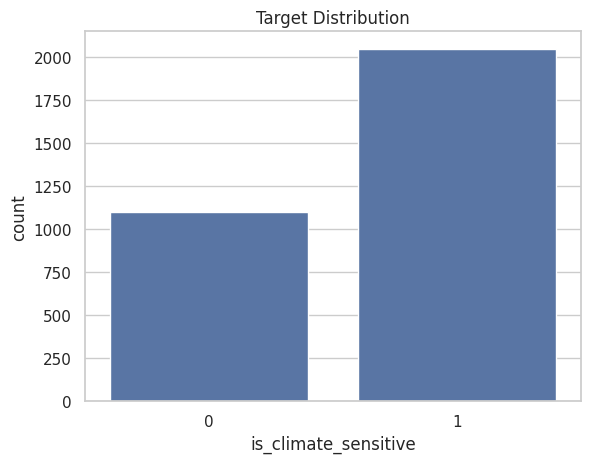

In [10]:

sns.countplot(x=TARGET, data=train)
plt.title("Target Distribution")
plt.show()


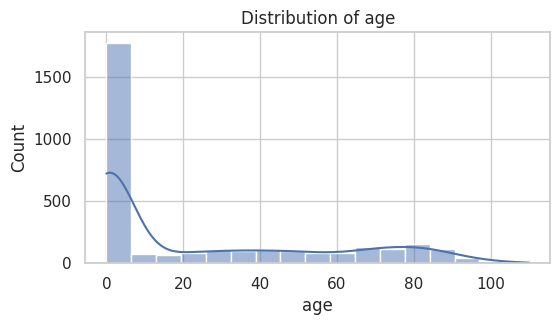

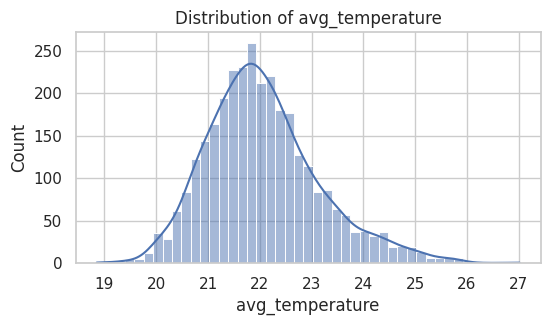

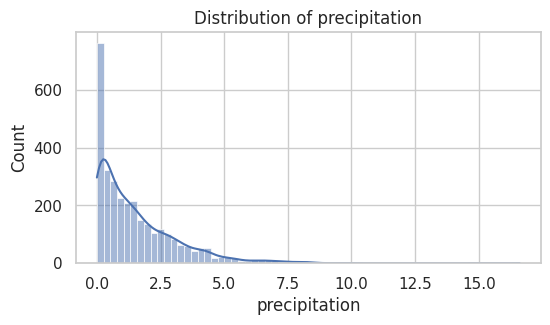

In [13]:

# Inspect some original and downloaded climate features
features_to_plot = [
    "age",
    "avg_temperature",
    "precipitation",
    "rain_sum_30d",
    "tavg_30d",
    "ndvi_30d",
    "elevation",
    "slope"
]

for col in features_to_plot:
    if col in train.columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(train[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()



## 🧹 Preprocessing and feature engineering

We keep the baseline simple and use:

- the original challenge features
- the downloaded climate/environmental features
- a few easy engineered features from `deathdate`


In [14]:

train_df = train.copy()
test_df = test.copy()

# Convert dates
train_df["deathdate"] = pd.to_datetime(train_df["deathdate"], errors="coerce")
test_df["deathdate"] = pd.to_datetime(test_df["deathdate"], errors="coerce")

# Simple date features
for df_ in [train_df, test_df]:
    df_["day_of_year"] = df_["deathdate"].dt.dayofyear
    df_["temperature_range"] = df_["max_temperature"] - df_["min_temperature"]
    df_["is_rainy_day_current"] = (df_["precipitation"] > 0).astype(int)

# Drop raw date after feature extraction
train_df = train_df.drop(columns=["deathdate"])
test_df = test_df.drop(columns=["deathdate"])

train_df.head()


,ID,zone,gender,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive,day_of_year,temperature_range,is_rainy_day_current
0,ID_1FE951BD,Rural,Male,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1,275,7.117375,1
1,ID_5927A443,Rural,Male,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1,5,10.334814,1
2,ID_C4E67025,Rural,Female,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1,45,8.633080,1
3,ID_44DC5CE9,Rural,Female,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1,46,9.101181,1
4,ID_33C677BB,Rural,Female,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0,46,9.101181,1


In [15]:

# Define target and features
X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET]

X_test = test_df.drop(columns=[ID_COL])

categorical_features = [c for c in X.columns if X[c].dtype == "object"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("\nNumber of numeric features:", len(numeric_features))
print("\nA few numeric features:", numeric_features[:20])


Categorical features: ['zone', 'gender', 'location']

Number of numeric features: 10

A few numeric features: ['age', 'avg_temperature', 'max_temperature', 'min_temperature', 'precipitation', 'latitude', 'longitude', 'day_of_year', 'temperature_range', 'is_rainy_day_current']



## ✂️ Train / Validation Split

We create a validation set to estimate baseline performance before generating a submission.


In [16]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


X_train shape: (2516, 13)
X_val shape: (630, 13)



## 🤖 Baseline Model

We use Logistic Regression as a simple and interpretable baseline.

Because the challenge metric includes both **F1** and **ROC-AUC**, this is a good baseline model to start with before trying stronger methods such as Random Forest, LightGBM, XGBoost, or CatBoost.


In [17]:
## Drop location from categorical features
categorical_features.remove("location")
categorical_features

['zone', 'gender']

In [18]:
## Check if latitude and longitude are in numerical features and drop them
numeric_features.remove("latitude")
numeric_features.remove("longitude")
numeric_features

['age',
 'avg_temperature',
 'max_temperature',
 'min_temperature',
 'precipitation',
 'day_of_year',
 'temperature_range',
 'is_rainy_day_current']

In [19]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        )
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['zone', 'gender']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_temperature',
                                                   'max_temperature',
                                                   'min_temperature',
                                                   'precipitation',
                                                   'day_of_year',
                                                   'temperature_range',
                                                   'is_rainy_day_current'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])


## 📈 Validation Performance

Official metric:

**Final Score = 0.60 × F1 + 0.40 × ROC-AUC**

Participants submit:
- `TargetF1`: binary prediction
- `TargetRAUC`: probability prediction


In [20]:

# Validation predictions
val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_proba >= 0.5).astype(int)

f1 = f1_score(y_val, val_pred_label)
auc = roc_auc_score(y_val, val_pred_proba)
final_score = 0.60 * f1 + 0.40 * auc

print(f"Validation F1-score: {f1:.6f}")
print(f"Validation ROC-AUC:  {auc:.6f}")
print(f"Validation Final Score: {final_score:.6f}")

print("\nClassification Report:")
print(classification_report(y_val, val_pred_label, digits=3))


Validation F1-score: 0.814010
Validation ROC-AUC:  0.766569
Validation Final Score: 0.795033

Classification Report:
              precision    recall  f1-score   support

           0      0.656     0.632     0.644       220
           1      0.806     0.822     0.814       410

    accuracy                          0.756       630
   macro avg      0.731     0.727     0.729       630
weighted avg      0.754     0.756     0.754       630



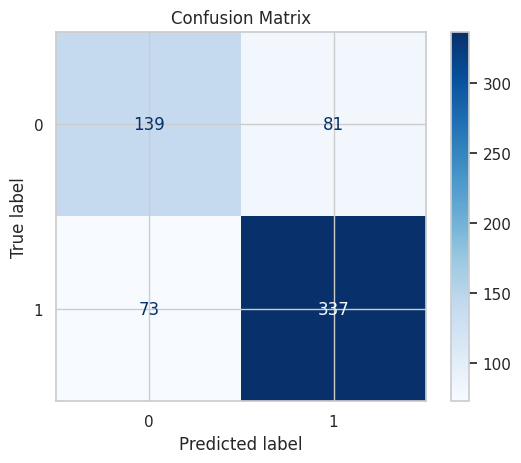

In [21]:

cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



## 📊 Feature Importance

We use permutation importance to see which features are most helpful to the baseline model.


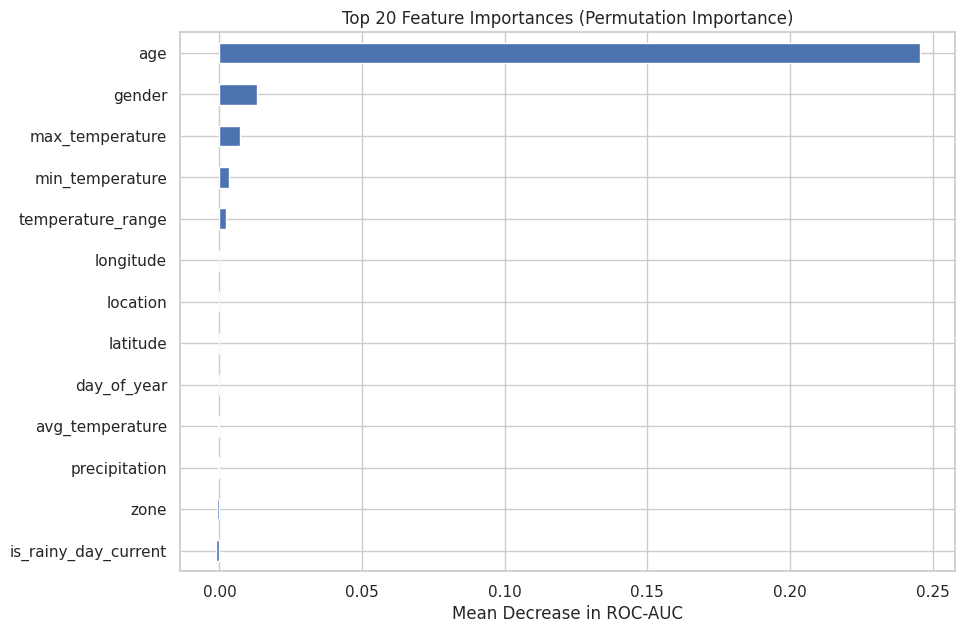

In [22]:

result = permutation_importance(
    pipeline,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

importances = pd.Series(result.importances_mean, index=X.columns)

(
    importances
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
    .plot(kind="barh", figsize=(10, 7))
)

plt.title("Top 20 Feature Importances (Permutation Importance)")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.show()



## 🚀 Train on Full Data and Predict on Test

Now retrain the baseline on the full training data and generate the submission file.


In [23]:

pipeline.fit(X, y)

test_pred_proba = pipeline.predict_proba(X_test)[:, 1]
test_pred_label = (test_pred_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET_F1: test_pred_label,
    TARGET_RAUC: test_pred_proba
})

submission.head()


,ID,TargetF1,TargetRAUC
0,ID_E760D84B,0,0.207577
1,ID_6EDEA907,0,0.397661
2,ID_B9FFC8D8,0,0.216026
3,ID_74C6C94E,0,0.146876
4,ID_0E02825D,1,0.657364


In [24]:

submission.to_csv("starter_submission.csv", index=False)
print("Submission file saved as starter_submission.csv")


Submission file saved as starter_submission.csv


In [30]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [31]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score

# ---------------------------------------------------------
# 1. Merge & Feature Engineering Pipeline
# ---------------------------------------------------------
train_df = train.merge(climate_features, on='ID', how='left')
test_df = test.merge(climate_features, on='ID', how='left')

# Extract Cyclical Date Features (Seasonality)
for df in [train_df, test_df]:
    date_col = 'deathdate_x' if 'deathdate_x' in df.columns else 'deathdate'
    date_series = pd.to_datetime(df[date_col])
    df['month'] = date_series.dt.month
    df['day_of_year'] = date_series.dt.dayofyear
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Location Risk Rate
loc_risk = train_df.groupby('location')['is_climate_sensitive'].mean().to_dict()
train_df['loc_risk_rate'] = train_df['location'].map(loc_risk)
test_df['loc_risk_rate'] = test_df['location'].map(loc_risk).fillna(train_df['is_climate_sensitive'].mean())

# Drop non-numeric / string key columns
drop_cols = ['is_climate_sensitive', 'ID', 'location', 'deathdate', 'deathdate_x', 'deathdate_y']

X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
y = train_df['is_climate_sensitive'].astype(int)
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()

# Domain Climate Ratio Features
for df in [X, X_test]:
    df['rain_intensity_30d'] = df['rain_sum_30d'] / (df['rain_days_30d'] + 1)
    df['ndvi_diff'] = df['ndvi_30d'] - df['ndvi_90d']
    df['rain_spike'] = df['rain_sum_7d'] / ((df['rain_sum_30d'] / 4.28) + 1e-5)
    df['age_heat_stress'] = df['age'] * df['hot_days_30d']
    df['temp_range_ratio'] = (df['max_temperature'] - df['min_temperature']) / (df['temp_range_mean_30d'] + 1e-5)

# Handle Categoricals natively
cat_cols = ['zone', 'gender']
for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

# Create numeric encoded copy for XGBoost
X_xgb = X.copy()
X_test_xgb = X_test.copy()
for c in cat_cols:
    X_xgb[c] = X_xgb[c].cat.codes
    X_test_xgb[c] = X_test_xgb[c].cat.codes

print(f"Data ready! Features: {X.shape[1]} (Categorical: {cat_cols})")

# ---------------------------------------------------------
# 2. Stratified 5-Fold Cross Validation Ensemble
# ---------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_oof = np.zeros(len(X))
xgb_oof = np.zeros(len(X))
cat_oof = np.zeros(len(X))

lgb_test = np.zeros(len(X_test))
xgb_test = np.zeros(len(X_test))
cat_test = np.zeros(len(X_test))

ratio = (y == 0).sum() / (y == 1).sum()

print("Training Ensemble across 5 Folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    X_tr_xgb, X_va_xgb = X_xgb.iloc[train_idx], X_xgb.iloc[val_idx]

    # Model 1: LightGBM
    model_lgb = lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.02, max_depth=5, num_leaves=25,
        subsample=0.8, colsample_bytree=0.7, scale_pos_weight=ratio, random_state=42+fold, verbose=-1
    )
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
    lgb_oof[val_idx] = model_lgb.predict_proba(X_va)[:, 1]
    lgb_test += model_lgb.predict_proba(X_test)[:, 1] / 5

    # Model 2: XGBoost
    model_xgb = XGBClassifier(
        n_estimators=600, learning_rate=0.02, max_depth=4, subsample=0.8,
        colsample_bytree=0.7, scale_pos_weight=ratio, random_state=42+fold, eval_metric='logloss'
    )
    model_xgb.fit(X_tr_xgb, y_tr, eval_set=[(X_va_xgb, y_va)], verbose=False)
    xgb_oof[val_idx] = model_xgb.predict_proba(X_va_xgb)[:, 1]
    xgb_test += model_xgb.predict_proba(X_test_xgb)[:, 1] / 5

    # Model 3: CatBoost
    model_cat = CatBoostClassifier(
        iterations=600, learning_rate=0.025, depth=5, scale_pos_weight=ratio,
        random_state=42+fold, cat_features=cat_cols, verbose=False
    )
    model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
    cat_oof[val_idx] = model_cat.predict_proba(X_va)[:, 1]
    cat_test += model_cat.predict_proba(X_test)[:, 1] / 5

# Blended Out-Of-Fold Predictions (40% LightGBM + 30% XGBoost + 30% CatBoost)
ensemble_oof = (0.40 * lgb_oof) + (0.30 * xgb_oof) + (0.30 * cat_oof)
ensemble_test = (0.40 * lgb_test) + (0.30 * xgb_test) + (0.30 * cat_test)

# ---------------------------------------------------------
# 3. Decision Threshold Search & Metrics Output
# ---------------------------------------------------------
best_thresh, best_f1 = 0.5, 0.0
for thresh in np.arange(0.20, 0.70, 0.01):
    score = f1_score(y, (ensemble_oof >= thresh).astype(int))
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

ens_auc = roc_auc_score(y, ensemble_oof)
ens_final = (best_f1 + ens_auc) / 2

print("\n--- 5-FOLD ENSEMBLE RESULTS ---")
print(f"Optimal F1 Threshold:  {best_thresh:.2f}")
print(f"Ensemble OOF F1-score: {best_f1:.6f}")
print(f"Ensemble OOF ROC-AUC:  {ens_auc:.6f}")
print(f"Ensemble CV Final:     {ens_final:.6f}")

# ---------------------------------------------------------
# 4. Save Final Formatted Submission
# ---------------------------------------------------------
# If SampleSubmission.csv exists, load it directly to guarantee matching IDs
try:
    sub = pd.read_csv('SampleSubmission.csv')
    sub['TargetF1'] = (ensemble_test >= best_thresh).astype(int)
    sub['TargetRAUC'] = ensemble_test
except FileNotFoundError:
    sub = pd.DataFrame({
        'ID': test_df['ID'],
        'TargetF1': (ensemble_test >= best_thresh).astype(int),
        'TargetRAUC': ensemble_test
    })

print("\n--- SUBMISSION PREVIEW ---")
print(sub.head())

sub.to_csv('final_submission.csv', index=False)
print("\nSaved formatted predictions to final_submission.csv")

Data ready! Features: 35 (Categorical: ['zone', 'gender'])
Training Ensemble across 5 Folds...

--- 5-FOLD ENSEMBLE RESULTS ---
Optimal F1 Threshold:  0.32
Ensemble OOF F1-score: 0.815754
Ensemble OOF ROC-AUC:  0.793668
Ensemble CV Final:     0.804711

--- SUBMISSION PREVIEW ---
            ID  TargetF1  TargetRAUC
0  ID_E760D84B         0    0.201479
1  ID_6EDEA907         1    0.561537
2  ID_B9FFC8D8         0    0.305803
3  ID_74C6C94E         0    0.281394
4  ID_0E02825D         1    0.646155

Saved formatted predictions to final_submission.csv


In [32]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score

# ---------------------------------------------------------
# 1. Merge & Feature Engineering
# ---------------------------------------------------------
train_df = train.merge(climate_features, on='ID', how='left')
test_df = test.merge(climate_features, on='ID', how='left')

# Date Seasonality Features
for df in [train_df, test_df]:
    date_col = 'deathdate_x' if 'deathdate_x' in df.columns else 'deathdate'
    date_series = pd.to_datetime(df[date_col])
    df['month'] = date_series.dt.month
    df['day_of_year'] = date_series.dt.dayofyear
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Location Baseline Risk Rate
loc_risk = train_df.groupby('location')['is_climate_sensitive'].mean().to_dict()
train_df['loc_risk_rate'] = train_df['location'].map(loc_risk)
test_df['loc_risk_rate'] = test_df['location'].map(loc_risk).fillna(train_df['is_climate_sensitive'].mean())

drop_cols = ['is_climate_sensitive', 'ID', 'location', 'deathdate', 'deathdate_x', 'deathdate_y']

X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
y = train_df['is_climate_sensitive'].astype(int)
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()

# Add Climate Deltas & Ratios
for df in [X, X_test]:
    df['rain_intensity_30d'] = df['rain_sum_30d'] / (df['rain_days_30d'] + 1)
    df['ndvi_diff'] = df['ndvi_30d'] - df['ndvi_90d']
    df['rain_spike'] = df['rain_sum_7d'] / ((df['rain_sum_30d'] / 4.28) + 1e-5)
    df['temp_spike'] = df['avg_temperature'] - df['tavg_30d']  # Heat anomaly feature
    df['age_heat_stress'] = df['age'] * df['hot_days_30d']
    df['temp_range_ratio'] = (df['max_temperature'] - df['min_temperature']) / (df['temp_range_mean_30d'] + 1e-5)

cat_cols = ['zone', 'gender']

# Standard Categorical Dtypes for LGBM & CatBoost
for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

# Numeric Integer Encodings for XGBoost
X_xgb = X.copy()
X_test_xgb = X_test.copy()
for c in cat_cols:
    X_xgb[c] = X_xgb[c].cat.codes
    X_test_xgb[c] = X_test_xgb[c].cat.codes

print(f"Data ready! Total features: {X.shape[1]}")

# ---------------------------------------------------------
# 2. 5-Fold Cross Validation (LGBM + XGB + CatBoost)
# ---------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_oof, xgb_oof, cat_oof = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))
lgb_test, xgb_test, cat_test = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))

ratio = (y == 0).sum() / (y == 1).sum()

print("Training 3-Model Ensemble across 5 Folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    X_tr_xgb, X_va_xgb = X_xgb.iloc[train_idx], X_xgb.iloc[val_idx]

    # 1. LightGBM
    model_lgb = lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.02, max_depth=5, num_leaves=25,
        subsample=0.8, colsample_bytree=0.7, scale_pos_weight=ratio, random_state=42+fold, verbose=-1
    )
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
    lgb_oof[val_idx] = model_lgb.predict_proba(X_va)[:, 1]
    lgb_test += model_lgb.predict_proba(X_test)[:, 1] / 5

    # 2. XGBoost
    model_xgb = XGBClassifier(
        n_estimators=600, learning_rate=0.02, max_depth=4, subsample=0.8,
        colsample_bytree=0.7, scale_pos_weight=ratio, random_state=42+fold, eval_metric='logloss'
    )
    model_xgb.fit(X_tr_xgb, y_tr, eval_set=[(X_va_xgb, y_va)], verbose=False)
    xgb_oof[val_idx] = model_xgb.predict_proba(X_va_xgb)[:, 1]
    xgb_test += model_xgb.predict_proba(X_test_xgb)[:, 1] / 5

    # 3. CatBoost
    model_cat = CatBoostClassifier(
        iterations=600, learning_rate=0.025, depth=5, scale_pos_weight=ratio,
        random_state=42+fold, cat_features=cat_cols, verbose=False
    )
    model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
    cat_oof[val_idx] = model_cat.predict_proba(X_va)[:, 1]
    cat_test += model_cat.predict_proba(X_test)[:, 1] / 5

# Weighted Blend: 40% LightGBM + 30% XGBoost + 30% CatBoost
ensemble_oof = (0.40 * lgb_oof) + (0.30 * xgb_oof) + (0.30 * cat_oof)
ensemble_test = (0.40 * lgb_test) + (0.30 * xgb_test) + (0.30 * cat_test)

# ---------------------------------------------------------
# 3. Threshold Search & Evaluation
# ---------------------------------------------------------
best_thresh, best_f1 = 0.5, 0.0
for thresh in np.arange(0.20, 0.70, 0.01):
    score = f1_score(y, (ensemble_oof >= thresh).astype(int))
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

ens_auc = roc_auc_score(y, ensemble_oof)
ens_final = (best_f1 + ens_auc) / 2

print("\n--- 3-MODEL ENSEMBLE RESULTS ---")
print(f"Optimal F1 Threshold:  {best_thresh:.2f}")
print(f"Ensemble OOF F1-score: {best_f1:.6f}")
print(f"Ensemble OOF ROC-AUC:  {ens_auc:.6f}")
print(f"Ensemble CV Final:     {ens_final:.6f}")

# ---------------------------------------------------------
# 4. Generate & Save Zindi Submission File
# ---------------------------------------------------------
try:
    sub = pd.read_csv('SampleSubmission.csv')
    sub['TargetF1'] = (ensemble_test >= best_thresh).astype(int)
    sub['TargetRAUC'] = ensemble_test
except FileNotFoundError:
    sub = pd.DataFrame({
        'ID': test_df['ID'],
        'TargetF1': (ensemble_test >= best_thresh).astype(int),
        'TargetRAUC': ensemble_test
    })

print("\n--- SUBMISSION PREVIEW ---")
print(sub.head())

sub.to_csv('catboost_ensemble_submission.csv', index=False)
print("\nSaved output to catboost_ensemble_submission.csv!")

Data ready! Total features: 36
Training 3-Model Ensemble across 5 Folds...

--- 3-MODEL ENSEMBLE RESULTS ---
Optimal F1 Threshold:  0.32
Ensemble OOF F1-score: 0.816281
Ensemble OOF ROC-AUC:  0.794735
Ensemble CV Final:     0.805508

--- SUBMISSION PREVIEW ---
            ID  TargetF1  TargetRAUC
0  ID_E760D84B         0    0.211997
1  ID_6EDEA907         1    0.568675
2  ID_B9FFC8D8         0    0.287820
3  ID_74C6C94E         0    0.284946
4  ID_0E02825D         1    0.643605

Saved output to catboost_ensemble_submission.csv!


In [33]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score

# ---------------------------------------------------------
# 1. Feature Preparation & Engineering
# ---------------------------------------------------------
train_df = train.merge(climate_features, on='ID', how='left')
test_df = test.merge(climate_features, on='ID', how='left')

# Date Seasonality Features
for df in [train_df, test_df]:
    date_col = 'deathdate_x' if 'deathdate_x' in df.columns else 'deathdate'
    date_series = pd.to_datetime(df[date_col])
    df['month'] = date_series.dt.month
    df['day_of_year'] = date_series.dt.dayofyear
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Location Risk Baseline
loc_risk = train_df.groupby('location')['is_climate_sensitive'].mean().to_dict()
train_df['loc_risk_rate'] = train_df['location'].map(loc_risk)
test_df['loc_risk_rate'] = test_df['location'].map(loc_risk).fillna(train_df['is_climate_sensitive'].mean())

drop_cols = ['is_climate_sensitive', 'ID', 'location', 'deathdate', 'deathdate_x', 'deathdate_y']

X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
y = train_df['is_climate_sensitive'].astype(int)
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()

# Add Climate Deltas & Ratios
for df in [X, X_test]:
    df['rain_intensity_30d'] = df['rain_sum_30d'] / (df['rain_days_30d'] + 1)
    df['ndvi_diff'] = df['ndvi_30d'] - df['ndvi_90d']
    df['rain_spike'] = df['rain_sum_7d'] / ((df['rain_sum_30d'] / 4.28) + 1e-5)
    df['temp_spike'] = df['avg_temperature'] - df['tavg_30d']
    df['age_heat_stress'] = df['age'] * df['hot_days_30d']
    df['temp_range_ratio'] = (df['max_temperature'] - df['min_temperature']) / (df['temp_range_mean_30d'] + 1e-5)

cat_cols = ['zone', 'gender']

for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

X_xgb = X.copy()
X_test_xgb = X_test.copy()
for c in cat_cols:
    X_xgb[c] = X_xgb[c].cat.codes
    X_test_xgb[c] = X_test_xgb[c].cat.codes

# ---------------------------------------------------------
# 2. Multi-Seed Training (3 Seeds x 5 Folds x 3 Models)
# ---------------------------------------------------------
SEEDS = [42, 100, 2026]
ratio = (y == 0).sum() / (y == 1).sum()

master_oof = np.zeros(len(X))
master_test = np.zeros(len(X_test))

print(f"Starting Multi-Seed Training across {len(SEEDS)} seeds...")

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n--- Running Seed {seed_idx + 1}/{len(SEEDS)} (Seed {seed}) ---")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    seed_oof_lgb, seed_oof_xgb, seed_oof_cat = np.zeros(len(X)), np.zeros(len(X)), np.zeros(len(X))
    seed_test_lgb, seed_test_xgb, seed_test_cat = np.zeros(len(X_test)), np.zeros(len(X_test)), np.zeros(len(X_test))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        X_tr_xgb, X_va_xgb = X_xgb.iloc[train_idx], X_xgb.iloc[val_idx]

        # 1. LightGBM
        model_lgb = lgb.LGBMClassifier(
            n_estimators=600, learning_rate=0.02, max_depth=5, num_leaves=25,
            subsample=0.8, colsample_bytree=0.7, scale_pos_weight=ratio, random_state=seed+fold, verbose=-1
        )
        model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
        seed_oof_lgb[val_idx] = model_lgb.predict_proba(X_va)[:, 1]
        seed_test_lgb += model_lgb.predict_proba(X_test)[:, 1] / 5

        # 2. XGBoost
        model_xgb = XGBClassifier(
            n_estimators=600, learning_rate=0.02, max_depth=4, subsample=0.8,
            colsample_bytree=0.7, scale_pos_weight=ratio, random_state=seed+fold, eval_metric='logloss'
        )
        model_xgb.fit(X_tr_xgb, y_tr, eval_set=[(X_va_xgb, y_va)], verbose=False)
        seed_oof_xgb[val_idx] = model_xgb.predict_proba(X_va_xgb)[:, 1]
        seed_test_xgb += model_xgb.predict_proba(X_test_xgb)[:, 1] / 5

        # 3. CatBoost
        model_cat = CatBoostClassifier(
            iterations=600, learning_rate=0.025, depth=5, scale_pos_weight=ratio,
            random_state=seed+fold, cat_features=cat_cols, verbose=False
        )
        model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50)
        seed_oof_cat[val_idx] = model_cat.predict_proba(X_va)[:, 1]
        seed_test_cat += model_cat.predict_proba(X_test)[:, 1] / 5

    # Blend models for this seed: 40% LGB + 30% XGB + 30% CAT
    seed_oof_blend = (0.40 * seed_oof_lgb) + (0.30 * seed_oof_xgb) + (0.30 * seed_oof_cat)
    seed_test_blend = (0.40 * seed_test_lgb) + (0.30 * seed_test_xgb) + (0.30 * seed_test_cat)

    # Accumulate into master arrays
    master_oof += seed_oof_blend / len(SEEDS)
    master_test += seed_test_blend / len(SEEDS)

# ---------------------------------------------------------
# 3. Final Evaluation & Submission Export
# ---------------------------------------------------------
best_thresh, best_f1 = 0.5, 0.0
for thresh in np.arange(0.20, 0.70, 0.01):
    score = f1_score(y, (master_oof >= thresh).astype(int))
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

ens_auc = roc_auc_score(y, master_oof)
ens_final = (best_f1 + ens_auc) / 2

print("\n==========================================")
print("MULTI-SEED ENSEMBLE RESULTS (15 FOLDS TOTAL)")
print("==========================================")
print(f"Optimal F1 Threshold:  {best_thresh:.2f}")
print(f"Master OOF F1-score:   {best_f1:.6f}")
print(f"Master OOF ROC-AUC:    {ens_auc:.6f}")
print(f"Master CV Final Score: {ens_final:.6f}")

try:
    sub = pd.read_csv('SampleSubmission.csv')
    sub['TargetF1'] = (master_test >= best_thresh).astype(int)
    sub['TargetRAUC'] = master_test
except FileNotFoundError:
    sub = pd.DataFrame({
        'ID': test_df['ID'],
        'TargetF1': (master_test >= best_thresh).astype(int),
        'TargetRAUC': master_test
    })

sub.to_csv('multiseed_ensemble_submission.csv', index=False)
print("\nSaved multi-seed submission file: multiseed_ensemble_submission.csv!")

Starting Multi-Seed Training across 3 seeds...

--- Running Seed 1/3 (Seed 42) ---

--- Running Seed 2/3 (Seed 100) ---

--- Running Seed 3/3 (Seed 2026) ---

MULTI-SEED ENSEMBLE RESULTS (15 FOLDS TOTAL)
Optimal F1 Threshold:  0.28
Master OOF F1-score:   0.814560
Master OOF ROC-AUC:    0.795257
Master CV Final Score: 0.804908

Saved multi-seed submission file: multiseed_ensemble_submission.csv!



## ✅ What’s Next?

This is still only a starter baseline. You can improve it by:

- trying stronger models such as Random Forest, LightGBM, XGBoost, or CatBoost
- tuning the threshold used for `TargetF1`
- engineering richer spatial features
- comparing models with and without downloaded climate features
- validating more carefully across space

Good luck, and happy modelling! 🚀
